# CVAE Student-t para generar escenarios BTC–ETH

Este notebook implementa **únicamente el mejor CVAE encontrado** para nuestro
dataset. La búsqueda de arquitectura e hiperparámetros ya se realizó y se
resume en la sección 3; no se repite aquí para mantener un recorrido didáctico:

1. cargamos el split temporal sin fugas;
2. entendemos por qué esta configuración fue seleccionada;
3. construimos el encoder, el espacio latente y el decoder Student-t;
4. entrenamos una sola vez el modelo definitivo;
5. generamos escenarios y comprobamos su calidad en test;
6. guardamos encoder, decoder, métricas y escenarios.

El objetivo no es predecir una única trayectoria futura. Queremos aprender una
**distribución condicional** de posibles retornos BTC–ETH durante los próximos
30 días, dado el estado de mercado observado durante los 60 días anteriores.

## Relación con el baseline y decisiones metodológicas

`01_block_bootstrap_multivariante.ipynb` es el **Baseline 1** del proyecto. Su
*moving block bootstrap* remuestrea bloques conjuntos BTC–ETH observados en
train: es transparente, no paramétrico y no condicionado. Este CVAE es el
modelo generativo aprendido que queremos contrastar con él.

Para que la comparación tenga sentido, conservamos las mismas decisiones:

- trayectorias conjuntas `[tiempo, BTC/ETH]` de 120 velas de seis horas;
- datos de ajuste restringidos a train y selección restringida a validación;
- retornos logarítmicos desnormalizados antes de evaluar;
- las seis familias del mismo `TrajectoryEvaluator` y la misma configuración;
- dependencia temporal calculada dentro de cada trayectoria, sin unir bordes;
- diagnóstico separado de fidelidad, riesgo, diversidad y memorización.

Una vez seleccionados ambos modelos con validación, el baseline y el CVAE se
evalúan sobre las mismas 1.826 trayectorias del test congelado. Por tanto, sus
métricas comunes sí permiten una comparación descriptiva fuera de muestra.

Hay una diferencia necesaria en el candidato: el bootstrap genera 5.000
trayectorias de una distribución agregada, mientras que el CVAE genera 20
escenarios **por cada condición**. En riesgo esto enfrenta un pronóstico
incondicional con uno condicional. Además, las ventanas reales se solapan, de
modo que la comparación no es un backtest con 1.826 observaciones
independientes ni una clasificación estadística definitiva.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
import json
import math
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers

tf.config.experimental.enable_op_determinism()
warnings.filterwarnings("ignore", category=UserWarning, module="keras")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from crypto_generative.evaluation import (
    CrossAssetDependenceConfig,
    DiversityMemorizationConfig,
    RiskMetricsConfig,
    TemporalDependenceConfig,
    TrajectoryEvaluator,
    TrajectoryMetricsConfig,
)

DATASET_PATH = ROOT / "data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz"
SPLIT_PATH = ROOT / "data/splits/binance/btc_eth_6h_c240_t120_purged_split.npz"
OUTPUT_DIR = ROOT / "outputs/cvae_best"

BATCH_SIZE = 128
MAX_EPOCHS = 60
PATIENCE = 10
SEED = 42
SCENARIOS_PER_CONDITION = 20

keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Dispositivos:", tf.config.list_physical_devices())
print("Raíz del proyecto detectada:", ROOT.name)

TensorFlow: 2.21.0
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Raíz del proyecto detectada: Taller_Generativos


## 1. Dataset y split temporal

Cada muestra tiene dos elementos:

- `condition_features`: 14 variables normalizadas que resumen los 60 días
  anteriores —retorno acumulado, volatilidad, drawdown, volumen, rango,
  correlación BTC–ETH y régimen de tendencia—;
- `target_returns`: 120 retornos de seis horas para BTC y ETH, equivalentes a
  los 30 días futuros que queremos modelar.

Usamos el split temporal congelado del proyecto. Entrenamiento, validación y
test están separados por purgas de 90 días, por lo que ninguna ventana comparte
timestamps entre bloques. La normalización fue ajustada solo con train.

In [2]:
with np.load(DATASET_PATH, allow_pickle=False) as data:
    conditions = data["condition_features"].astype(np.float32)
    targets = data["target_returns"].astype(np.float32)
    feature_names = data["feature_names"].copy()
    assets = data["assets"].copy()
    return_mean = data["return_mean"].astype(np.float32)
    return_scale = data["return_scale"].astype(np.float32)

with np.load(SPLIT_PATH, allow_pickle=False) as split:
    train_ids = split["train_sample_ids"].copy()
    validation_ids = split["validation_sample_ids"].copy()
    test_ids = split["test_sample_ids"].copy()

x_train, c_train = targets[train_ids], conditions[train_ids]
x_validation, c_validation = targets[validation_ids], conditions[validation_ids]
x_test, c_test = targets[test_ids], conditions[test_ids]

dataset_summary = pd.DataFrame(
    {
        "bloque": ["train", "validación", "test"],
        "muestras": [len(x_train), len(x_validation), len(x_test)],
        "objetivo": [str(x_train.shape[1:]), str(x_validation.shape[1:]), str(x_test.shape[1:])],
        "condición": [str(c_train.shape[1:]), str(c_validation.shape[1:]), str(c_test.shape[1:])],
    }
)
dataset_summary

,bloque,muestras,objetivo,condición
0,train,4710,"(120, 2)","(14,)"
1,validación,1832,"(120, 2)","(14,)"
2,test,1826,"(120, 2)","(14,)"


Las 9.096 ventanas se desplazan una vela cada vez y se solapan mucho. Por eso
son suficientes para entrenar y comparar modelos, pero no equivalen a 9.096
historias independientes. En test conservamos también un control de 16 anclas
separadas por 120 velas para no exagerar la evidencia estadística.

In [3]:
def make_dataset(x, c, *, shuffle, seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices(
        {"trajectory": x, "condition": c}
    )
    if shuffle:
        dataset = dataset.shuffle(len(x), seed=seed, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_dataset = make_dataset(x_train, c_train, shuffle=True)
validation_dataset = make_dataset(x_validation, c_validation, shuffle=False)

print("Barajado reproducible y operaciones TensorFlow deterministas: activados")

Barajado reproducible y operaciones TensorFlow deterministas: activados


## 2. Configuración definitiva

Toda la configuración del modelo está reunida aquí. No hay un espacio de
búsqueda oculto ni parámetros que cambien entre celdas.

In [4]:
@dataclass(frozen=True)
class CVAEConfig:
    name: str = "student_medium_l8_b01"
    filters: tuple[int, int] = (32, 64)
    dense_units: int = 96
    condition_units: tuple[int, int] = (24, 48)
    latent_dim: int = 8
    beta: float = 0.01
    free_bits: float = 0.02
    warmup_epochs: int = 10
    student_df: float = 5.0


CONFIG = CVAEConfig()
pd.Series(asdict(CONFIG), name="valor").to_frame()

,valor
name,student_medium_l8_b01
filters,"(32, 64)"
dense_units,96
condition_units,"(24, 48)"
latent_dim,8
beta,0.01
free_bits,0.02
warmup_epochs,10
student_df,5.0


## 3. Qué búsqueda hicimos y por qué ganó este modelo

Antes de simplificar el notebook se ejecutó un benchmark determinista de **39
configuraciones**. Todas usaron exactamente el mismo train, validación, semilla
inicial y métricas. La selección no se basó solo en la reconstrucción: el score
combinó media, volatilidad, cuantiles, correlación BTC–ETH, autocorrelación de
magnitud, retorno acumulado, drawdown y calibración por regímenes.

### Familias comparadas

| Decisión | Opciones comprobadas | Resultado |
|---|---|---|
| Distribución de salida | MSE, Gaussiana bivariante, Student-t bivariante | Student-t fue claramente superior por sus colas gruesas |
| Capacidad | filtros `(16,32)`, `(32,64)`, `(48,96)`; densas 64–128 | la capacidad media generalizó mejor |
| Espacio latente | 4, 8, 12 y 16 dimensiones | 8 fue el mejor compromiso entre diversidad y estabilidad |
| Regularización | varios `beta` entre 0.001 y 0.03; *free bits* 0–0.05 | `beta=0.01`, `free_bits=0.02` mantuvo el KL activo sin dominar la NLL |
| Condición | 14 resúmenes, historia Conv1D, historia GRU y modos híbridos | el resumen fue más estable; la historia completa añadió capacidad, pero no señal útil suficiente |
| Colas | Student-t con 3, 4, 5, 7 y 10 grados de libertad | 5 equilibró centro y extremos |
| Trayectoria | pérdida auxiliar acumulada con pesos 0.01–0.30 | no mejoró el equilibrio global de forma estable |

Los scores de una sola semilla no eran suficientes. Reentrenamos los tres
mejores candidatos con semillas 7, 42 y 123 y calculamos
`score robusto = media + desviación típica`. Así penalizamos una arquitectura
que solo funciona con una inicialización afortunada.

| Candidato finalista | Condición | Score medio | Desv. | Score robusto |
|---|---:|---:|---:|---:|
| **`student_medium_l8_b01`** | resumen | **0.1241** | **0.0173** | **0.1414** |
| `student_hconv_l4` | híbrida Conv1D | 0.1295 | 0.0253 | 0.1547 |
| `student_medium_l16_df5` | resumen | 0.1391 | 0.0460 | 0.1851 |

Por familias, el mejor score de la ronda inicial fue aproximadamente 0.106
para Student-t, 0.209 para Gaussiana y 0.911 para MSE. MSE generaba la media de
muchas trayectorias posibles y sufría **subdispersión**; la Gaussiana mejoró la
volatilidad, pero infrarrepresentó las colas. Student-t resolvió ambos problemas
sin separar BTC y ETH.

La API de Binance también se auditó antes del benchmark. Solo había 18 velas de
seis horas nuevas por activo: ampliaban ligeramente test, pero no train ni el
número de regímenes. Por ello mantuvimos el snapshot congelado y comparable.

## 4. Cómo funciona el CVAE ganador

### 4.1 Qué distribución aprende

Llamamos `x` a la trayectoria futura `(120, 2)` y `c` al estado de mercado
`(14,)`. El objetivo es aproximar:

\[
p_\theta(x\mid c)=\int p_\theta(x\mid z,c)\,p(z)\,dz,
\qquad p(z)=\mathcal N(0,I).
\]

`z` representa factores futuros que no están determinados por la condición:
intensidad del movimiento, dirección, shocks o combinaciones de ellos. Para
generar escenarios nuevos muestreamos distintos `z` manteniendo fija `c`.

Durante entrenamiento desconocemos qué `z` explica cada trayectoria real. El
encoder aprende una aproximación posterior:

\[
q_\phi(z\mid x,c)=\mathcal N(\mu_\phi(x,c),
\operatorname{diag}(\sigma_\phi^2(x,c))).
\]

El decoder aprende `p_theta(x | z,c)`. La condición aparece en ambos lados: en
el encoder ayuda a separar lo ya conocido de lo incierto; en el decoder hace
que una misma zona latente produzca resultados diferentes según el mercado.

### 4.2 Encoder

Las dos Conv1D recorren el eje temporal, no el eje de activos:

```text
trayectoria (120, 2)
  -> Conv1D(32, kernel=5, stride=2)  -> (60, 32)
  -> Conv1D(64, kernel=5, stride=2)  -> (30, 64)
  -> Flatten                         -> 1920

condición (14) -> Dense(24) -> Dense(48)

concat(1920, 48) -> Dense(96)
                 -> z_mean (8)
                 -> z_log_var (8)
```

La media y el logaritmo de la varianza parametrizan el posterior. No hacemos
que el encoder emita un punto fijo, porque necesitamos que el latente conserve
incertidumbre.

### 4.3 Truco de reparametrización

Muestrear directamente de una distribución impediría propagar gradientes. Lo
reescribimos como una transformación diferenciable:

\[
\epsilon\sim\mathcal N(0,I),\qquad
z=\mu+\exp(\tfrac12\log\sigma^2)\odot\epsilon.
\]

La aleatoriedad queda en `epsilon`; los parámetros `mu` y `log_var` continúan
dentro del grafo de TensorFlow.

In [5]:
@keras.utils.register_keras_serializable(package="crypto_generative")
class Sampling(layers.Layer):
    """Aplica z = media + desviación * epsilon."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def encode_condition(condition_input, prefix):
    """Proyecta las 14 variables a una representación compacta."""
    x = layers.Dense(
        CONFIG.condition_units[0], activation="swish", name=f"{prefix}_condition_24"
    )(condition_input)
    return layers.Dense(
        CONFIG.condition_units[1], activation="swish", name=f"{prefix}_condition_48"
    )(x)


def build_encoder_decoder(trajectory_shape=(120, 2), condition_dim=14):
    steps, n_assets = trajectory_shape

    trajectory_input = keras.Input(shape=trajectory_shape, name="trajectory")
    condition_input = keras.Input(shape=(condition_dim,), name="condition")
    x = trajectory_input
    for index, filters in enumerate(CONFIG.filters, start=1):
        x = layers.Conv1D(
            filters, 5, strides=2, padding="same", activation="swish",
            name=f"encoder_conv_{index}",
        )(x)
    x = layers.Flatten(name="encoder_flatten")(x)
    encoded_condition = encode_condition(condition_input, "encoder")
    x = layers.Concatenate(name="encoder_concat")([x, encoded_condition])
    x = layers.Dense(CONFIG.dense_units, activation="swish", name="encoder_dense")(x)
    z_mean = layers.Dense(CONFIG.latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(CONFIG.latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])
    encoder = keras.Model(
        {"trajectory": trajectory_input, "condition": condition_input},
        [z_mean, z_log_var, z],
        name="cvae_encoder",
    )

    latent_input = keras.Input(shape=(CONFIG.latent_dim,), name="latent")
    decoder_condition = keras.Input(shape=(condition_dim,), name="condition")
    decoded_condition = encode_condition(decoder_condition, "decoder")
    x = layers.Concatenate(name="decoder_concat")([latent_input, decoded_condition])
    x = layers.Dense(
        (steps // 4) * CONFIG.filters[-1], activation="swish", name="decoder_dense"
    )(x)
    x = layers.Reshape((steps // 4, CONFIG.filters[-1]), name="decoder_reshape")(x)
    for index, filters in enumerate(reversed(CONFIG.filters), start=1):
        x = layers.UpSampling1D(2, name=f"decoder_upsampling_{index}")(x)
        x = layers.Conv1D(
            filters, 5, padding="same", activation="swish",
            name=f"decoder_conv_{index}",
        )(x)
    raw_output = layers.Conv1D(
        2 * n_assets + 1, 5, padding="same", name="decoder_output"
    )(x)
    decoder = keras.Model(
        {"latent": latent_input, "condition": decoder_condition},
        raw_output,
        name="cvae_decoder",
    )
    return encoder, decoder


encoder, decoder = build_encoder_decoder(
    trajectory_shape=x_train.shape[1:], condition_dim=c_train.shape[1]
)
print("Parámetros encoder:", f"{encoder.count_params():,}")
print("Parámetros decoder:", f"{decoder.count_params():,}")

Parámetros encoder: 202,792
Parámetros decoder: 142,621


### 4.4 Decoder Student-t bivariante

El decoder expande `z` y `c` hasta recuperar 120 pasos. En cada paso no devuelve
un retorno fijo, sino cinco parámetros:

```text
[loc_BTC, loc_ETH, raw_scale_BTC, raw_scale_ETH, raw_rho]
```

Convertimos `raw_scale` con `softplus` para garantizar escalas positivas y
`raw_rho` con `0.95*tanh` para garantizar una matriz de correlación válida. La
salida define una Student-t bivariante con 5 grados de libertad. Frente a una
Gaussiana, asigna más probabilidad a movimientos extremos; frente a dos
distribuciones independientes, conserva la dependencia contemporánea BTC–ETH.

Para residuos estandarizados `u_BTC` y `u_ETH`, la distancia de Mahalanobis es:

\[
d^2=\frac{u_{BTC}^2-2\rho u_{BTC}u_{ETH}+u_{ETH}^2}{1-\rho^2}.
\]

La reconstrucción es la NLL Student-t media. Minimizarla obliga al modelo a
aprender simultáneamente localización, volatilidad, colas y correlación.

### 4.5 KL, beta y free bits

La pérdida total es:

\[
\mathcal L=\operatorname{NLL}_{Student-t}(x;\theta(z,c))
+\beta\,D_{KL}(q_\phi(z\mid x,c)\Vert\mathcal N(0,I)).
\]

- La NLL enseña calidad de reconstrucción probabilística.
- La KL acerca el posterior al prior normal que usaremos al generar.
- `beta=0.01` evita que la KL destruya demasiado pronto la información futura.
- El *warm-up* aumenta beta gradualmente durante 10 épocas.
- `free_bits=0.02` deja un pequeño presupuesto informativo por dimensión antes
  de penalizarla; así reducimos el riesgo de *posterior collapse*.

Si la KL cayese prácticamente a cero y las muestras fueran casi iguales,
sospecharíamos colapso. En el modelo final la KL permanece alrededor de 3–4,
señal de que el decoder utiliza el latente.

In [6]:
class ConditionalVAE(keras.Model):
    """CVAE con likelihood Student-t bivariante y KL regularizada."""

    def __init__(self, encoder, decoder):
        super().__init__(name=f"cvae_{CONFIG.name}")
        self.encoder = encoder
        self.decoder = decoder
        self.beta_weight = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.raw_kl_loss_tracker = keras.metrics.Mean(name="raw_kl_loss")
        self.regularized_kl_loss_tracker = keras.metrics.Mean(name="regularized_kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.raw_kl_loss_tracker,
            self.regularized_kl_loss_tracker,
        ]

    @staticmethod
    def split_decoder_output(raw_output):
        location = raw_output[..., :2]
        scale = tf.nn.softplus(raw_output[..., 2:4]) + 1e-3
        rho = 0.95 * tf.nn.tanh(raw_output[..., 4])
        return location, scale, rho

    def reconstruction_loss(self, trajectory, raw_output):
        location, scale, rho = self.split_decoder_output(raw_output)
        standardized = (trajectory - location) / scale
        btc, eth = standardized[..., 0], standardized[..., 1]
        one_minus_rho_sq = tf.maximum(1.0 - tf.square(rho), 1e-4)
        mahalanobis = (
            tf.square(btc) - 2.0 * rho * btc * eth + tf.square(eth)
        ) / one_minus_rho_sq
        half_log_determinant = (
            tf.math.log(scale[..., 0])
            + tf.math.log(scale[..., 1])
            + 0.5 * tf.math.log(one_minus_rho_sq)
        )
        df = tf.cast(CONFIG.student_df, tf.float32)
        dimensions = tf.constant(2.0, dtype=tf.float32)
        constant = (
            tf.math.lgamma(df / 2.0)
            + 0.5 * dimensions * tf.math.log(df * math.pi)
            - tf.math.lgamma((df + dimensions) / 2.0)
        )
        element_loss = (
            constant
            + half_log_determinant
            + 0.5 * (df + dimensions) * tf.math.log1p(mahalanobis / df)
        )
        return tf.reduce_mean(element_loss)

    def calculate_losses(self, trajectory, condition, training):
        z_mean, z_log_var, sampled_z = self.encoder(
            {"trajectory": trajectory, "condition": condition}, training=training
        )
        z = sampled_z if training else z_mean
        raw_output = self.decoder(
            {"latent": z, "condition": condition}, training=training
        )
        reconstruction = self.reconstruction_loss(trajectory, raw_output)
        kl_per_dimension = -0.5 * (
            1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        mean_kl_per_dimension = tf.reduce_mean(kl_per_dimension, axis=0)
        raw_kl = tf.reduce_sum(mean_kl_per_dimension)
        regularized_kl = tf.reduce_sum(
            tf.maximum(mean_kl_per_dimension, CONFIG.free_bits)
        )
        total = reconstruction + self.beta_weight * regularized_kl
        return total, reconstruction, raw_kl, regularized_kl

    def train_step(self, data):
        inputs = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            losses = self.calculate_losses(
                inputs["trajectory"], inputs["condition"], training=True
            )
        gradients = tape.gradient(losses[0], self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        return self.update_trackers(*losses)

    def test_step(self, data):
        inputs = data[0] if isinstance(data, tuple) else data
        losses = self.calculate_losses(
            inputs["trajectory"], inputs["condition"], training=False
        )
        return self.update_trackers(*losses)

    def update_trackers(self, total, reconstruction, raw_kl, regularized_kl):
        for tracker, value in zip(self.metrics, (total, reconstruction, raw_kl, regularized_kl)):
            tracker.update_state(value)
        return {metric.name: metric.result() for metric in self.metrics}


class BetaWarmup(keras.callbacks.Callback):
    """Aumenta beta linealmente hasta CONFIG.beta."""

    def on_epoch_begin(self, epoch, logs=None):
        fraction = min(1.0, (epoch + 1) / CONFIG.warmup_epochs)
        self.model.beta_weight.assign(CONFIG.beta * fraction)


model = ConditionalVAE(encoder, decoder)
model.compile(optimizer=keras.optimizers.Adam(1e-3))

## 5. Entrenamiento del único modelo

Entrenamos con `train` y usamos validación únicamente para *early stopping*.
Restauramos los pesos de la mejor época según `val_total_loss`. El test no
participa en ninguna decisión de entrenamiento.

In [7]:
keras.utils.set_random_seed(SEED)
callbacks = [
    BetaWarmup(),
    keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        patience=PATIENCE,
        mode="min",
        restore_best_weights=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

started = time.perf_counter()
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=0,
)
elapsed = time.perf_counter() - started

print(f"Épocas completadas: {len(history.epoch)}")
print(f"Tiempo: {elapsed:.1f} s")
print(f"KL final de validación: {history.history['val_raw_kl_loss'][-1]:.4f}")

Épocas completadas: 18
Tiempo: 13.0 s
KL final de validación: 4.1646


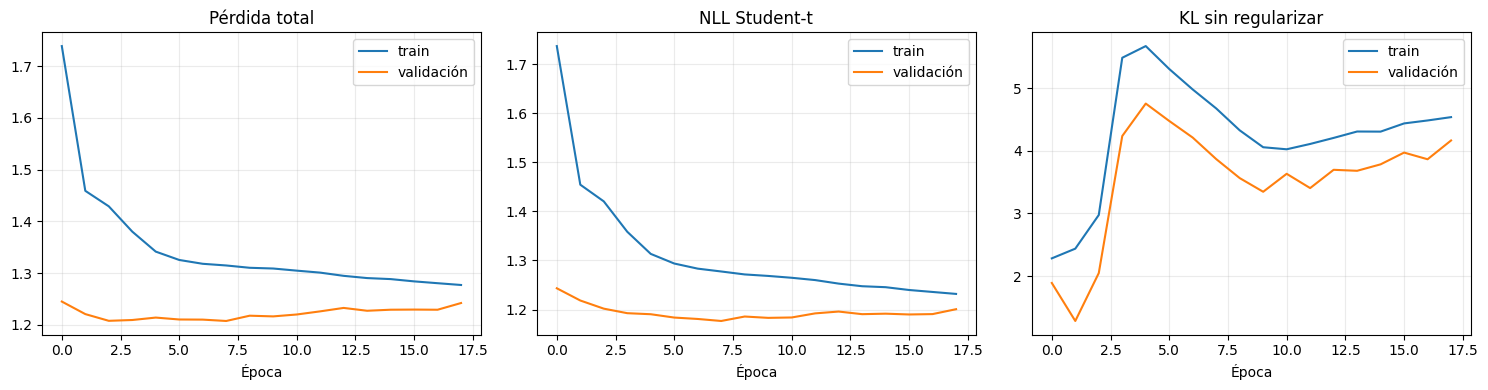

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, metric, title in zip(
    axes,
    ("total_loss", "reconstruction_loss", "raw_kl_loss"),
    ("Pérdida total", "NLL Student-t", "KL sin regularizar"),
):
    axis.plot(history.history[metric], label="train")
    axis.plot(history.history[f"val_{metric}"], label="validación")
    axis.set_title(title)
    axis.set_xlabel("Época")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

## 6. Generación de escenarios

Para generar no usamos el encoder: muestreamos `z ~ N(0,I)` y pasamos `z` y
la condición al decoder. Después muestreamos una Student-t bivariante con los
parámetros predichos. El mismo denominador chi-cuadrado para BTC y ETH conserva
la dependencia de cola conjunta.

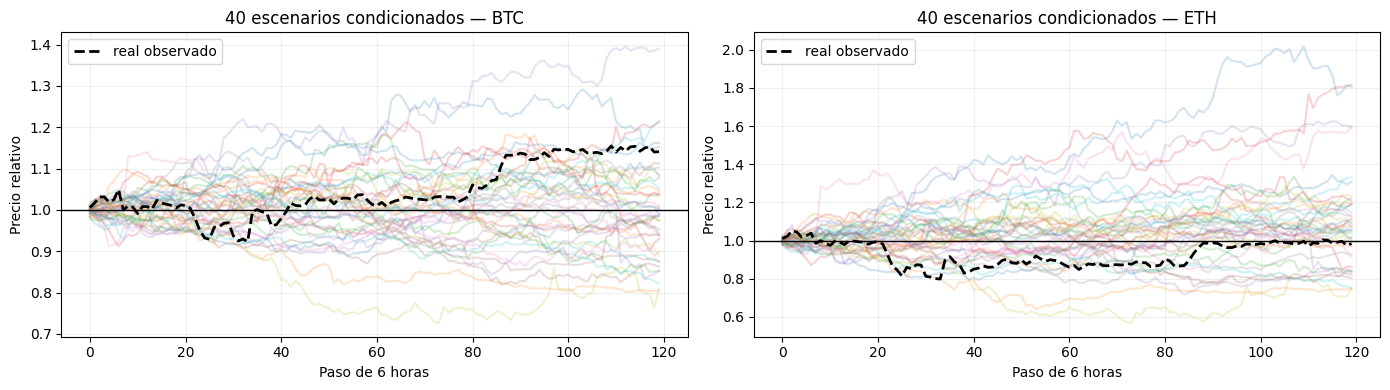

In [9]:
def parse_decoder_output(raw_output):
    location = raw_output[..., :2]
    raw_scale = raw_output[..., 2:4]
    scale = np.log1p(np.exp(-np.abs(raw_scale))) + np.maximum(raw_scale, 0) + 1e-3
    rho = 0.95 * np.tanh(raw_output[..., 4])
    return location, scale, rho


def sample_decoder(decoder, condition_batch, seed):
    rng = np.random.default_rng(seed)
    latent = rng.normal(size=(len(condition_batch), CONFIG.latent_dim)).astype(np.float32)
    raw_output = np.asarray(
        decoder({"latent": latent, "condition": condition_batch}, training=False)
    )
    location, scale, rho = parse_decoder_output(raw_output)
    independent = rng.normal(size=location.shape)
    correlated = np.empty_like(independent)
    correlated[..., 0] = independent[..., 0]
    correlated[..., 1] = (
        rho * independent[..., 0]
        + np.sqrt(np.maximum(1.0 - np.square(rho), 1e-6)) * independent[..., 1]
    )
    chi_square = rng.chisquare(CONFIG.student_df, size=location.shape[:-1] + (1,))
    student_noise = correlated / np.sqrt(chi_square / CONFIG.student_df)
    return (location + scale * student_noise).astype(np.float32)


example_condition = np.repeat(c_test[:1], 40, axis=0)
example_generated = sample_decoder(decoder, example_condition, seed=20_260_807)
example_returns = example_generated * return_scale[None, None, :] + return_mean[None, None, :]
real_example_returns = x_test[0] * return_scale[None, :] + return_mean[None, :]
generated_prices = np.exp(np.cumsum(example_returns, axis=1))
real_price = np.exp(np.cumsum(real_example_returns, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for asset_index, (axis, asset) in enumerate(zip(axes, assets)):
    axis.plot(generated_prices[:, :, asset_index].T, alpha=0.2)
    axis.plot(real_price[:, asset_index], "k--", linewidth=2, label="real observado")
    axis.axhline(1.0, color="black", linewidth=1)
    axis.set_title(f"40 escenarios condicionados — {asset}")
    axis.set_xlabel("Paso de 6 horas")
    axis.set_ylabel("Precio relativo")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## 7. Evaluación común en test

Usamos ahora `crypto_generative.evaluation.TrajectoryEvaluator`, el contrato
común del equipo. Esto elimina el evaluador artesanal que tenía el notebook y
permite comparar CVAE, *normalizing flow* y bootstrap con exactamente las
mismas definiciones.

El contrato tiene dos reglas importantes:

1. recibe retornos logarítmicos **en unidades originales**, nunca normalizados;
2. riesgo conserva `[condiciones, draws, tiempo, activos]`; las demás familias
   reciben el mismo tensor aplanado a `[trayectorias, tiempo, activos]`.

Generamos 20 escenarios por condición. Son suficientes para comparar las
familias descriptivas; VaR/ES al 99 % debe seguir interpretándose como
exploratorio porque una cola condicional tan extrema necesitaría más draws.

In [10]:
test_conditions_flat = np.repeat(c_test, SCENARIOS_PER_CONDITION, axis=0)
generated_normalized_flat = sample_decoder(
    decoder, test_conditions_flat, seed=20_260_805
)
generated_conditional_normalized = generated_normalized_flat.reshape(
    len(x_test), SCENARIOS_PER_CONDITION, *x_test.shape[1:]
)

reference_returns = (
    x_test * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float64)
training_returns = (
    x_train * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float64)
generated_conditional_returns = (
    generated_conditional_normalized * return_scale[None, None, None, :]
    + return_mean[None, None, None, :]
).astype(np.float64)
generated_returns = generated_conditional_returns.reshape(
    -1, generated_conditional_returns.shape[-2], generated_conditional_returns.shape[-1]
)

evaluator = TrajectoryEvaluator(assets=assets.tolist())
print("Referencia:", reference_returns.shape)
print("Candidato condicional:", generated_conditional_returns.shape)
print("Candidato aplanado:", generated_returns.shape)

Referencia: (1826, 120, 2)
Candidato condicional: (1826, 20, 120, 2)
Candidato aplanado: (36520, 120, 2)


### 7.1 Marginales

Compara media, desviación, asimetría, curtosis, cuantiles, extremos y
Wasserstein-1 por activo. Los umbrales extremos se ajustan solo con la
referencia y después se aplican al CVAE.

In [11]:
marginal_report = evaluator.evaluate_marginals(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
)
marginal_table = pd.DataFrame(marginal_report.to_records())
marginal_table[
    [
        "asset",
        "reference_standard_deviation",
        "candidate_standard_deviation",
        "reference_excess_kurtosis",
        "candidate_excess_kurtosis",
        "reference_extreme_frequency",
        "candidate_extreme_frequency",
        "normalized_wasserstein_1",
    ]
]

,asset,reference_standard_deviation,candidate_standard_deviation,reference_excess_kurtosis,candidate_excess_kurtosis,reference_extreme_frequency,candidate_extreme_frequency,normalized_wasserstein_1
0,BTC,0.010913,0.010934,4.823215,12.746241,0.010054,0.006582,0.12164
1,ETH,0.017073,0.016541,4.760664,10.946716,0.010268,0.006667,0.09958


### 7.2 Dependencia temporal y BTC–ETH

La evaluación temporal mide ACF de retornos, retornos absolutos y cuadrados,
persistencia de volatilidad y clustering de extremos sin unir artificialmente
el final de una trayectoria con el inicio de otra. La evaluación cruzada añade
correlación contemporánea y móvil, calma/estrés, caídas conjuntas y dependencia
de cola inferior.

In [12]:
temporal_report = evaluator.evaluate_temporal_dependence(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=TemporalDependenceConfig(
        max_lag=20,
        volatility_window=20,
        high_volatility_quantile=0.90,
        extreme_quantile=0.99,
        extreme_clustering_window=4,
    ),
)
temporal_table = pd.DataFrame(temporal_report.to_records())
temporal_table[
    [
        "asset",
        "return_acf_rmse",
        "absolute_return_acf_rmse",
        "squared_return_acf_rmse",
        "volatility_persistence_absolute_error",
        "extreme_clustering_ratio_absolute_error",
    ]
]

,asset,return_acf_rmse,absolute_return_acf_rmse,squared_return_acf_rmse,volatility_persistence_absolute_error,extreme_clustering_ratio_absolute_error
0,BTC,0.025117,0.054011,0.070458,0.595524,3.553357
1,ETH,0.023705,0.066776,0.042465,0.907537,0.714353


In [13]:
cross_asset_report = evaluator.evaluate_cross_asset_dependence(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=CrossAssetDependenceConfig(
        rolling_window=20,
        stress_quantile=0.90,
        joint_drop_quantile=0.05,
        lower_tail_quantile=0.05,
    ),
)
cross_asset_table = pd.DataFrame(cross_asset_report.to_records())
cross_asset_table[
    [
        "asset_pair",
        "reference_contemporaneous_correlation",
        "candidate_contemporaneous_correlation",
        "contemporaneous_correlation_absolute_error",
        "rolling_correlation_wasserstein_1",
        "stress_correlation_absolute_error",
        "joint_drop_probability_absolute_error",
        "lower_tail_dependence_absolute_error",
    ]
].T

,0
asset_pair,BTC-ETH
reference_contemporaneous_correlation,0.846945
candidate_contemporaneous_correlation,0.823954
contemporaneous_correlation_absolute_error,0.022991
rolling_correlation_wasserstein_1,0.021621
stress_correlation_absolute_error,0.049015
joint_drop_probability_absolute_error,0.012259
lower_tail_dependence_absolute_error,0.164613


### 7.3 Trayectorias, riesgo y diversidad

Estas familias responden a preguntas distintas:

- **trayectoria:** ¿coinciden retorno final, volatilidad anualizada, drawdown y
  tiempos hasta pérdidas?;
- **riesgo:** ¿están calibrados VaR y Expected Shortfall de BTC, ETH y cartera
  60/40 para cada condición?;
- **diversidad:** ¿hay escenarios repetidos, memorización de train, mala
  cobertura o un discriminador capaz de separar fácilmente real y sintético?

In [14]:
trajectory_report = evaluator.evaluate_trajectories(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
trajectory_table = pd.DataFrame(trajectory_report.to_records())
trajectory_table.pivot(
    index="metric", columns="asset", values="normalized_wasserstein_1"
).rename_axis(columns=None)

,BTC,ETH
metric,,
final_cumulative_return,0.435967,0.240293
intrahorizon_maximum_return,0.579474,0.195823
intrahorizon_minimum_return,0.226764,0.241523
maximum_drawdown,0.198102,0.225991
maximum_drawdown_duration_steps,0.229022,0.190268
realized_volatility,0.151040,0.481618
time_to_minimum_value_steps,0.106547,0.032730


In [15]:
risk_report = evaluator.evaluate_risk(
    reference_paths=reference_returns,
    candidate_paths=generated_conditional_returns,
    config=RiskMetricsConfig(
        confidence_levels=(0.95, 0.99),
        portfolio_weights=(0.60, 0.40),
        portfolio_name="portfolio_60_40",
        es_stability_repetitions=100,
        es_stability_sample_size=1_000,
        random_state=SEED,
    ),
)
risk_table = pd.DataFrame(risk_report.to_records())
risk_table[
    [
        "target",
        "confidence_level",
        "unconditional_var_absolute_error",
        "unconditional_es_absolute_error",
        "exception_rate",
        "expected_exception_rate",
        "coverage_absolute_error",
    ]
]

,target,confidence_level,unconditional_var_absolute_error,unconditional_es_absolute_error,exception_rate,expected_exception_rate,coverage_absolute_error
0,BTC,0.95,0.075197,0.043385,0.217963,0.05,0.167963
1,BTC,0.99,0.022546,0.016217,0.179628,0.01,0.169628
2,ETH,0.95,0.094605,0.060858,0.201533,0.05,0.151533
3,ETH,0.99,0.035269,0.009912,0.165936,0.01,0.155936
4,portfolio_60_40,0.95,0.091817,0.060735,0.209200,0.05,0.159200
5,portfolio_60_40,0.99,0.041683,0.001760,0.177437,0.01,0.167437


In [16]:
diversity_report = evaluator.evaluate_diversity_and_memorization(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    training_paths=training_returns,
    config=DiversityMemorizationConfig(
        max_paths_per_set=2_000,
        projection_dimensions=24,
        neighbor_candidates=8,
        near_memorization_quantile=0.01,
        coverage_radius_quantile=0.95,
        discriminator_repetitions=5,
        random_state=SEED,
    ),
)
diversity_table = pd.DataFrame(diversity_report.to_records())
diversity_table[
    [
        "candidate_unique_fraction",
        "candidate_near_duplicate_fraction",
        "exact_training_match_fraction",
        "near_memorization_fraction",
        "reference_coverage_fraction",
        "regime_total_variation_distance",
        "discriminator_accuracy_mean",
    ]
].T.rename(columns={0: "valor"})

,valor
candidate_unique_fraction,1.000000
candidate_near_duplicate_fraction,0.129000
exact_training_match_fraction,0.000000
near_memorization_fraction,0.064000
reference_coverage_fraction,0.947974
regime_total_variation_distance,0.139468
discriminator_accuracy_mean,0.744526


### 7.4 Diagnósticos visuales comparables con el baseline

Repetimos las mismas vistas del notebook de *block bootstrap*. No introducen
métricas nuevas: hacen visibles los informes comunes calculados arriba. Ambos
modelos usan ahora el mismo test congelado y la misma referencia real, por lo
que podemos comparar directamente estos diagnósticos descriptivos. Al
interpretarlos debemos conservar la diferencia entre el bootstrap agregado y
los escenarios condicionales del CVAE.

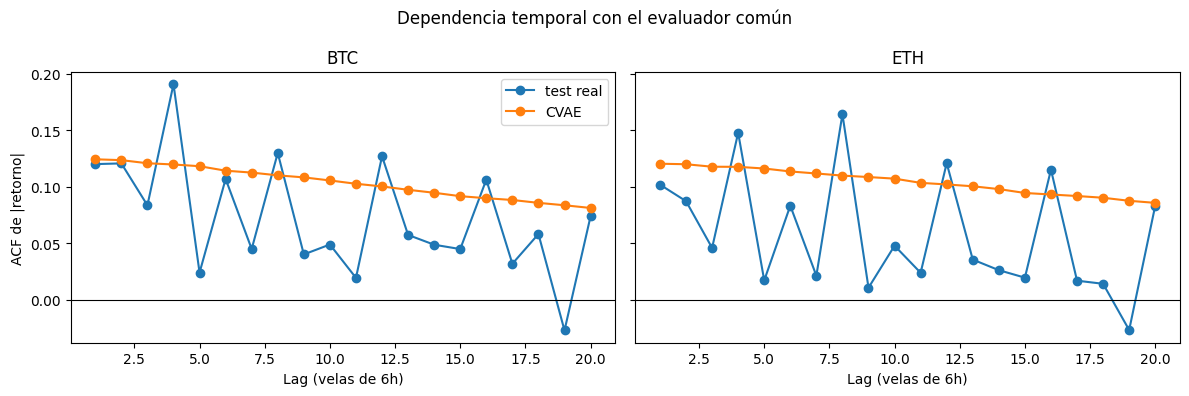

In [17]:
temporal_lags = np.arange(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, asset in zip(axes, assets):
    asset_report = temporal_report.by_asset[str(asset)]
    axis.plot(
        temporal_lags,
        asset_report.reference.absolute_return_acf,
        marker="o",
        label="test real",
    )
    axis.plot(
        temporal_lags,
        asset_report.candidate.absolute_return_acf,
        marker="o",
        label="CVAE",
    )
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set(title=str(asset), xlabel="Lag (velas de 6h)")
axes[0].set_ylabel("ACF de |retorno|")
axes[0].legend()
fig.suptitle("Dependencia temporal con el evaluador común")
fig.tight_layout()
plt.show()

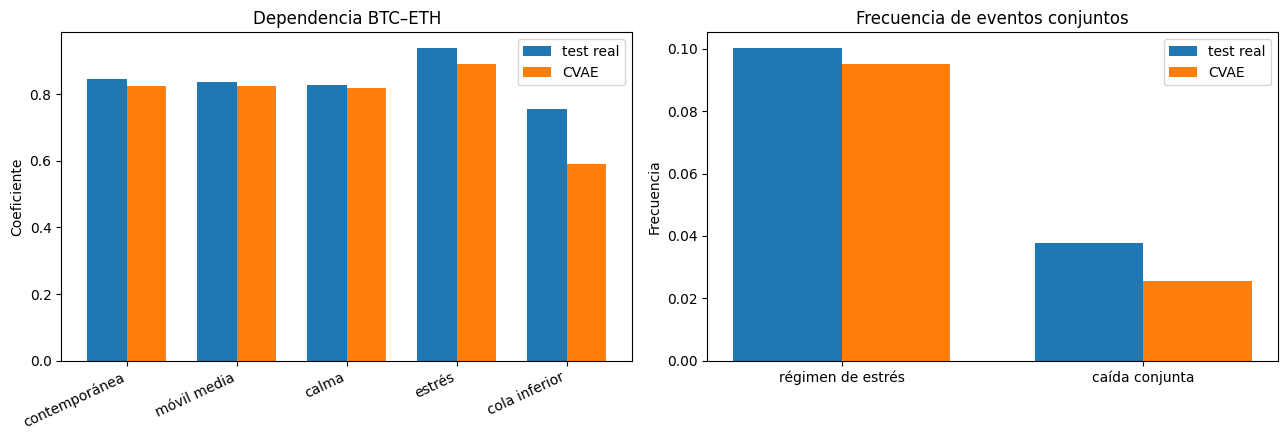

In [18]:
dependence_labels = [
    "contemporánea",
    "móvil media",
    "calma",
    "estrés",
    "cola inferior",
]
reference_dependence = [
    cross_asset_report.reference.contemporaneous_correlation,
    cross_asset_report.reference.rolling_correlation.mean,
    cross_asset_report.reference.calm_correlation,
    cross_asset_report.reference.stress_correlation,
    cross_asset_report.reference.lower_tail_dependence,
]
candidate_dependence = [
    cross_asset_report.candidate.contemporaneous_correlation,
    cross_asset_report.candidate.rolling_correlation.mean,
    cross_asset_report.candidate.calm_correlation,
    cross_asset_report.candidate.stress_correlation,
    cross_asset_report.candidate.lower_tail_dependence,
]

x_positions = np.arange(len(dependence_labels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(x_positions - 0.18, reference_dependence, 0.36, label="test real")
axes[0].bar(x_positions + 0.18, candidate_dependence, 0.36, label="CVAE")
axes[0].set_xticks(x_positions, dependence_labels, rotation=25, ha="right")
axes[0].set(title="Dependencia BTC–ETH", ylabel="Coeficiente")
axes[0].legend()

event_labels = ["régimen de estrés", "caída conjunta"]
reference_events = [
    cross_asset_report.reference.stress_frequency,
    cross_asset_report.reference.joint_drop_probability,
]
candidate_events = [
    cross_asset_report.candidate.stress_frequency,
    cross_asset_report.candidate.joint_drop_probability,
]
event_positions = np.arange(len(event_labels))
axes[1].bar(event_positions - 0.18, reference_events, 0.36, label="test real")
axes[1].bar(event_positions + 0.18, candidate_events, 0.36, label="CVAE")
axes[1].set_xticks(event_positions, event_labels)
axes[1].set(title="Frecuencia de eventos conjuntos", ylabel="Frecuencia")
axes[1].legend()
fig.tight_layout()
plt.show()

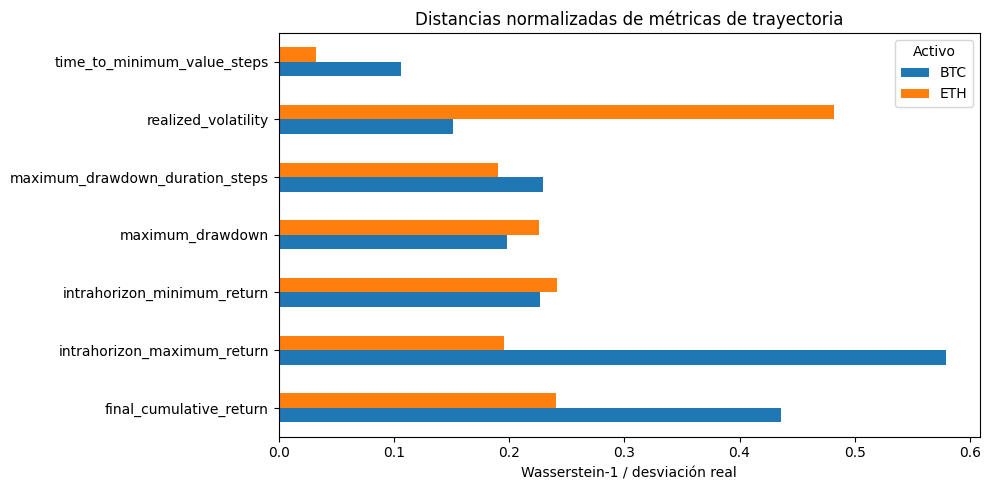

In [19]:
trajectory_distance_table = trajectory_table.pivot(
    index="metric",
    columns="asset",
    values="normalized_wasserstein_1",
)
axis = trajectory_distance_table.plot.barh(
    figsize=(10, 5),
    title="Distancias normalizadas de métricas de trayectoria",
)
axis.set(xlabel="Wasserstein-1 / desviación real", ylabel="")
axis.legend(title="Activo")
axis.figure.tight_layout()
plt.show()

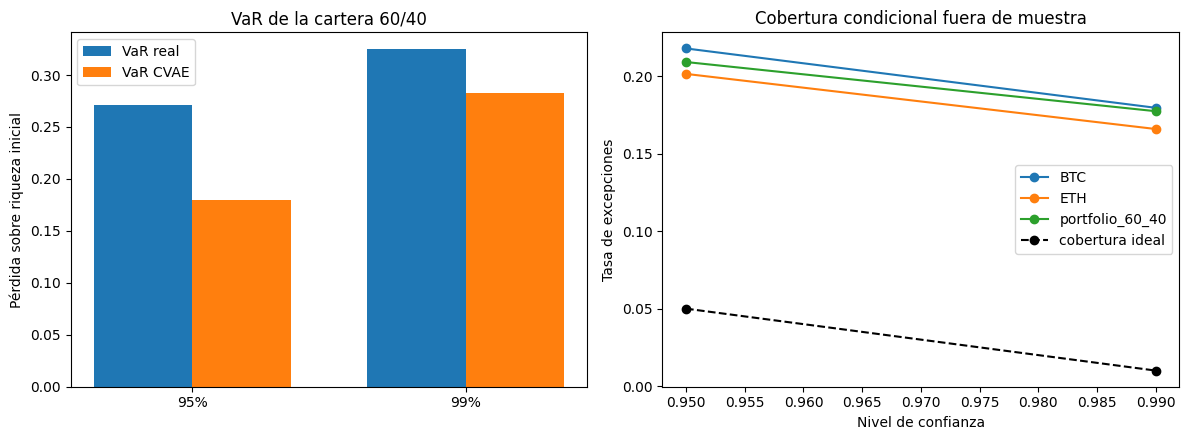

In [20]:
portfolio_risk = risk_table.loc[risk_table["target"].eq("portfolio_60_40")]
risk_positions = np.arange(len(portfolio_risk))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    risk_positions - 0.18,
    portfolio_risk["reference_unconditional_var"],
    0.36,
    label="VaR real",
)
axes[0].bar(
    risk_positions + 0.18,
    portfolio_risk["candidate_unconditional_var"],
    0.36,
    label="VaR CVAE",
)
axes[0].set_xticks(
    risk_positions,
    [f"{level:.0%}" for level in portfolio_risk["confidence_level"]],
)
axes[0].set(title="VaR de la cartera 60/40", ylabel="Pérdida sobre riqueza inicial")
axes[0].legend()

for target, target_table in risk_table.groupby("target", sort=False):
    axes[1].plot(
        target_table["confidence_level"],
        target_table["exception_rate"],
        marker="o",
        label=target,
    )
axes[1].plot(
    portfolio_risk["confidence_level"],
    portfolio_risk["expected_exception_rate"],
    color="black",
    linestyle="--",
    marker="o",
    label="cobertura ideal",
)
axes[1].set(
    title="Cobertura condicional fuera de muestra",
    xlabel="Nivel de confianza",
    ylabel="Tasa de excepciones",
)
axes[1].legend()
fig.tight_layout()
plt.show()

### Interpretación de riesgo

El CVAE es **poco conservador al 95 %**. Para la cartera 60/40 estima un VaR
del 17.93 %, frente al 27.11 % observado en test, y aparecen un 20.92 % de
excepciones en lugar del 5 % esperado. BTC y ETH muestran el mismo patrón, con
tasas de excepción del 21.80 % y 20.15 %.

Al 99 % los VaR agregados quedan más cerca, pero las excepciones siguen entre
16.59 % y 17.96 %, muy lejos del 1 % esperado. Con solo 20 draws por condición,
ese percentil se aproxima prácticamente con el peor escenario disponible. El
gráfico sirve para detectar la infracalibración, no para validar el CVAE como
motor de capital económico.

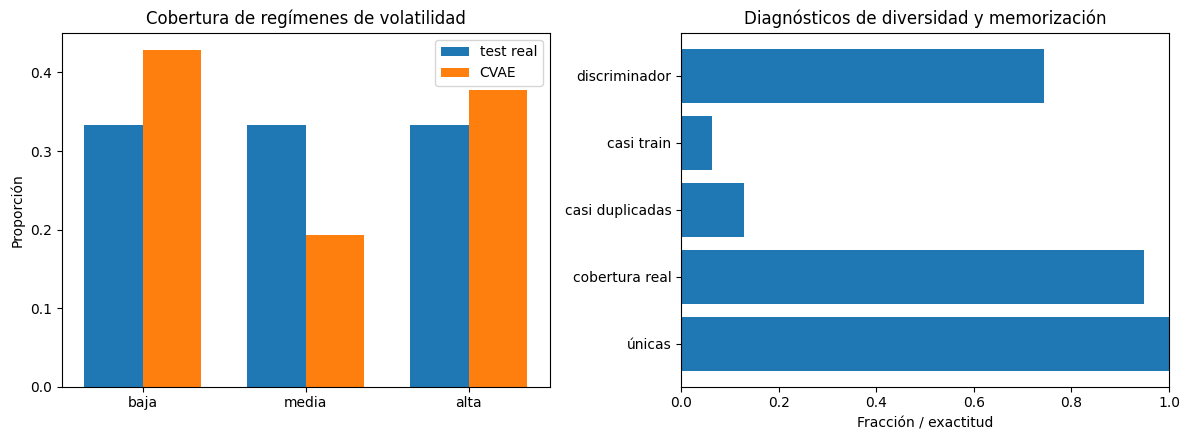

In [21]:
regime_names = ["low", "medium", "high"]
regime_positions = np.arange(len(regime_names))
reference_regimes = [
    diversity_report.reference_regime_proportions[name]
    for name in regime_names
]
candidate_regimes = [
    diversity_report.candidate_regime_proportions[name]
    for name in regime_names
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(regime_positions - 0.18, reference_regimes, 0.36, label="test real")
axes[0].bar(regime_positions + 0.18, candidate_regimes, 0.36, label="CVAE")
axes[0].set_xticks(regime_positions, ["baja", "media", "alta"])
axes[0].set(title="Cobertura de regímenes de volatilidad", ylabel="Proporción")
axes[0].legend()

diagnostic_names = [
    "únicas",
    "cobertura real",
    "casi duplicadas",
    "casi train",
    "discriminador",
]
diagnostic_values = [
    diversity_report.candidate_unique_fraction,
    diversity_report.reference_coverage_fraction,
    diversity_report.candidate_near_duplicate_fraction,
    diversity_report.near_memorization_fraction,
    diversity_report.discriminator_accuracy_mean,
]
axes[1].barh(diagnostic_names, diagnostic_values)
axes[1].set(
    title="Diagnósticos de diversidad y memorización",
    xlabel="Fracción / exactitud",
    xlim=(0, 1),
)
fig.tight_layout()
plt.show()

### Interpretación de diversidad y memorización

Las 2.000 trayectorias sintéticas inspeccionadas son únicas y ninguna coincide
exactamente con train. La cobertura geométrica de test alcanza el 94.8 %, y
la proporción de casi memorización es 6.4 %. No parece haber copia literal del
conjunto de entrenamiento.

Sin embargo, el CVAE concentra poco peso en el régimen medio (19.4 % frente a
33.3 % real), con distancia total entre regímenes de 0.139. Además, un
discriminador distingue real de sintético con 74.5 % de exactitud. Igual que
en el baseline, diversidad no implica fidelidad: el generador cubre bastante
bien el espacio, pero todavía deja una firma estadística reconocible.

También repetimos el control con una ancla cada 120 velas. Solo quedan 16
objetivos no solapados, de modo que esta tabla es una comprobación de
sensibilidad, no una estimación precisa de eventos extremos.

In [22]:
non_overlapping_ids = np.arange(0, len(x_test), 120)
non_overlapping_conditions_flat = np.repeat(
    c_test[non_overlapping_ids], SCENARIOS_PER_CONDITION, axis=0
)
non_overlapping_generated_normalized = sample_decoder(
    decoder, non_overlapping_conditions_flat, seed=20_260_806
)
non_overlapping_reference = reference_returns[non_overlapping_ids]
non_overlapping_generated_returns = (
    non_overlapping_generated_normalized * return_scale[None, None, :]
    + return_mean[None, None, :]
).astype(np.float64)

non_overlapping_marginal_report = evaluator.evaluate_marginals(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_generated_returns,
)
non_overlapping_trajectory_report = evaluator.evaluate_trajectories(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_generated_returns,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
print("Anclas no solapadas:", len(non_overlapping_ids))
display(
    pd.DataFrame(non_overlapping_marginal_report.to_records())[
        ["asset", "normalized_wasserstein_1"]
    ].rename(columns={"normalized_wasserstein_1": "W1 marginal normalizada"})
)
pd.DataFrame(non_overlapping_trajectory_report.to_records()).pivot(
    index="metric", columns="asset", values="normalized_wasserstein_1"
).rename_axis(columns=None)

Anclas no solapadas: 16


,asset,W1 marginal normalizada
0,BTC,0.052214
1,ETH,0.061093


,BTC,ETH
metric,,
final_cumulative_return,0.366766,0.196182
intrahorizon_maximum_return,0.514825,0.115053
intrahorizon_minimum_return,0.244029,0.270884
maximum_drawdown,0.228511,0.293190
maximum_drawdown_duration_steps,0.222511,0.127162
realized_volatility,0.206732,0.476981
time_to_minimum_value_steps,0.142177,0.107476


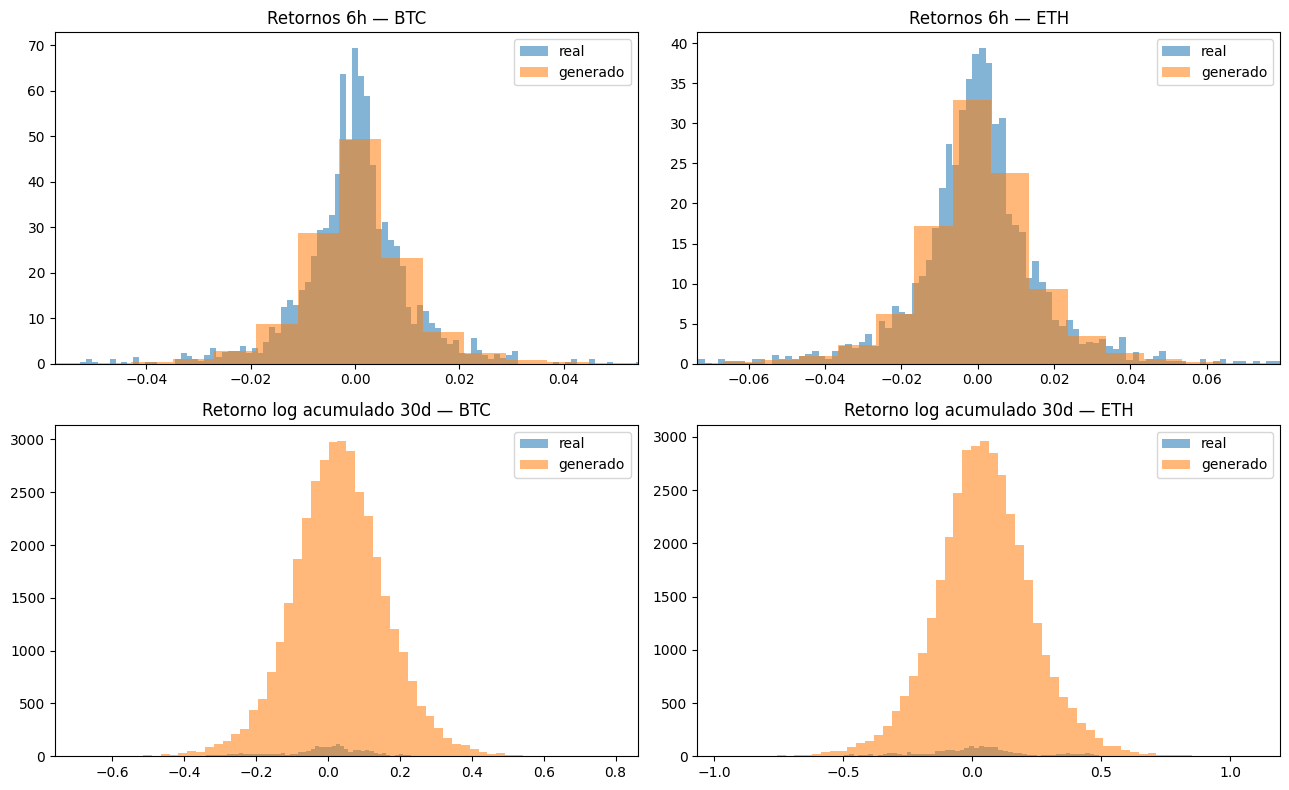

In [23]:
real_test_returns = reference_returns
generated_test_returns = generated_returns

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for asset_index, asset in enumerate(assets):
    axes[0, asset_index].hist(real_test_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="real")
    axes[0, asset_index].hist(generated_test_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="generado")
    axes[0, asset_index].set_title(f"Retornos 6h — {asset}")
    axes[0, asset_index].set_xlim(
        np.quantile(real_test_returns[:, :, asset_index], 0.001),
        np.quantile(real_test_returns[:, :, asset_index], 0.999),
    )
    axes[0, asset_index].legend()
    axes[1, asset_index].hist(real_test_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="real")
    axes[1, asset_index].hist(generated_test_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="generado")
    axes[1, asset_index].set_title(f"Retorno log acumulado 30d — {asset}")
    axes[1, asset_index].legend()
plt.tight_layout()
plt.show()

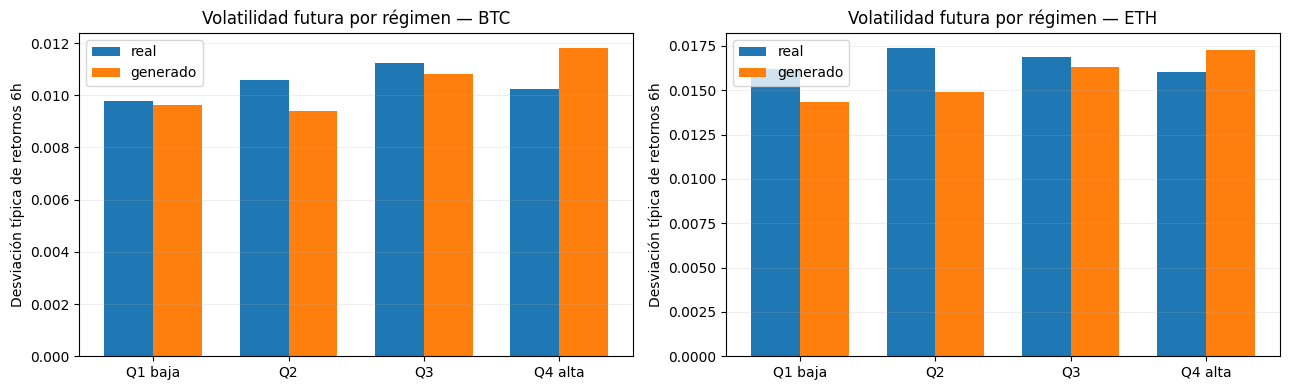

In [24]:
test_regime_score = c_test[:, [1, 7]].mean(axis=1)
regime_ids = np.digitize(test_regime_score, np.quantile(test_regime_score, [0.25, 0.5, 0.75]))
generated_grouped_returns = generated_conditional_returns
real_unrepeated_returns = reference_returns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = ["Q1 baja", "Q2", "Q3", "Q4 alta"]
positions = np.arange(4)
for asset_index, (axis, asset) in enumerate(zip(axes, assets)):
    real_vol, generated_vol = [], []
    for regime_id in range(4):
        mask = regime_ids == regime_id
        real_vol.append(real_unrepeated_returns[mask, :, asset_index].std(1).mean())
        generated_vol.append(generated_grouped_returns[mask, :, :, asset_index].std(2).mean())
    axis.bar(positions - 0.18, real_vol, 0.36, label="real")
    axis.bar(positions + 0.18, generated_vol, 0.36, label="generado")
    axis.set_xticks(positions, labels)
    axis.set_title(f"Volatilidad futura por régimen — {asset}")
    axis.set_ylabel("Desviación típica de retornos 6h")
    axis.grid(axis="y", alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## 8. Guardado reproducible

In [25]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
encoder.save(OUTPUT_DIR / "encoder.keras")
decoder.save(OUTPUT_DIR / "decoder.keras")
np.savez_compressed(
    OUTPUT_DIR / "test_scenarios.npz",
    generated_normalized=generated_normalized_flat,
    generated_conditional_returns=generated_conditional_returns,
    generated_returns=generated_returns,
    real_normalized=x_test,
    real_returns=reference_returns,
    conditions=c_test,
    assets=assets,
)

metadata = {
    "selected_config": asdict(CONFIG),
    "selection_evidence": {
        "candidates_compared": 39,
        "stability_seeds": [7, 42, 123],
        "criterion": "mean_validation_score_plus_standard_deviation",
        "robust_validation_score": 0.141395,
    },
    "tensorflow_deterministic_ops": True,
    "epochs_completed": len(history.epoch),
    "train_samples": len(x_train),
    "validation_samples": len(x_validation),
    "test_samples": len(x_test),
    "scenarios_per_condition": SCENARIOS_PER_CONDITION,
    "evaluation": {
        "marginal": marginal_report.to_dict(),
        "temporal": temporal_report.to_dict(),
        "cross_asset": cross_asset_report.to_dict(),
        "trajectory": trajectory_report.to_dict(),
        "risk": risk_report.to_dict(),
        "diversity_and_memorization": diversity_report.to_dict(),
    },
    "non_overlapping_sensitivity": {
        "anchors": len(non_overlapping_ids),
        "marginal": non_overlapping_marginal_report.to_dict(),
        "trajectory": non_overlapping_trajectory_report.to_dict(),
    },
}
(OUTPUT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("Artefactos guardados en:", OUTPUT_DIR.relative_to(ROOT))

Artefactos guardados en: outputs/cvae_best


## Conclusión

Hemos entrenado un único CVAE Student-t, seleccionado previamente entre 39
alternativas. El modelo conserva un KL activo, reproduce razonablemente la
volatilidad y la dependencia BTC–ETH, y genera trayectorias diversas para una
misma condición.

La evaluación final utiliza el módulo común del repositorio para medir
marginales, dependencia temporal y cruzada, trayectorias, riesgo y
diversidad/memorización. Esto permite comparar el CVAE con el baseline y con
futuros modelos sin cambiar las definiciones de las métricas.

En esta ejecución, las desviaciones marginales quedan muy próximas a las
reales: 0.01093 frente a 0.01091 en BTC y 0.01654 frente a 0.01707 en ETH. La
correlación contemporánea BTC–ETH también se conserva bien (error absoluto
0.023), pero el modelo exagera la curtosis y todavía pierde dependencia de
cola inferior (error 0.165). En trayectoria, el retorno final acumulado es más
difícil que el retorno marginal: su Wasserstein normalizado es 0.436 en BTC y
0.240 en ETH.

La diversidad es real —100 % de trayectorias únicas, ningún duplicado exacto
de train y cobertura de referencia del 94.8 %—, aunque un discriminador sigue
separando real y sintético con un 74.5 % de acierto. Esto confirma que no hay
simple copia del entrenamiento, pero sí diferencias estructurales detectables.

La principal limitación continúa siendo el retorno acumulado a 30 días: las
distribuciones reales muestran regímenes y multimodalidad que el CVAE suaviza.
Además, solo disponemos de 16 anclas de test no solapadas y 20 draws por
condición. En VaR 95 %, las excepciones observadas rondan el 20–22 % en vez del
5 % esperado: el riesgo condicional está claramente infracalibrado. Con 20
draws, además, el percentil 99 % apenas puede resolverse. Por tanto, este es el
mejor CVAE comprobado para el taller y un buen generador exploratorio, pero no
es todavía un simulador de riesgo extremo para producción.